# SemEval 2026 Task C - Colab Training Notebook

Notebook pronto per Colab/VS Code per addestrare un classificatore a 4 classi per il Task B.
- Usa i mapping in `task_C/`
- Supporta dataset ufficiale HF o file locali
- Esporta una submission nel formato `ID,label` richiesto dal checker della repo

In [ ]:
# Install dependencies
# In Colab puoi lasciare queste celle attive. In locale puoi commentarle.
!pip -q install -U transformers datasets scikit-learn accelerate pandas pyarrow

In [ ]:
import os
import json
import random
import warnings
import inspect

import numpy as np
import pandas as pd
import torch
from datasets import Dataset, load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

os.environ["WANDB_DISABLED"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [ ]:
class CFG:
    model_name = "microsoft/unixcoder-base"
    max_len = 512
    num_labels = 4

    # Local repo paths
    repo_root = os.path.abspath("..")
    task_dir = os.path.join(repo_root, "task_C")
    local_train_path = os.path.join(task_dir, "train.parquet")
    local_val_path = os.path.join(task_dir, "validation.parquet")
    local_test_path = os.path.join(task_dir, "test.parquet")
    local_fallback_path = os.path.join(task_dir, "task_c_trial.parquet")

    # HuggingFace dataset fallback
    hf_dataset_name = "DaniilOr/SemEval-2026-Task13"
    hf_subset = "C"

    # batch_size = 4
    # eval_batch_size = 8
    batch_size = 64
    eval_batch_size = 128
    epochs = 3
    lr = 2e-5
    weight_decay = 0.01
    fp16 = torch.cuda.is_available()
    # num_workers = 2
    num_workers = 4
    output_dir = os.path.join(repo_root, "task_C", "colab_outputs")
    submission_path = os.path.join(repo_root, "task_C", "submission_task_C.csv")


os.makedirs(CFG.output_dir, exist_ok=True)

with open(os.path.join(CFG.task_dir, "id_to_label.json"), "r", encoding="utf-8") as f:
    id2label = {int(k): v for k, v in json.load(f).items()}
with open(os.path.join(CFG.task_dir, "label_to_id.json"), "r", encoding="utf-8") as f:
    label2id = {k: int(v) for k, v in json.load(f).items()}

print(id2label)

{0: 'human', 1: 'machine', 2: 'hybrid', 3: 'adversarial'}


In [ ]:
def pick_eval_key():
    params = inspect.signature(TrainingArguments.__init__).parameters
    return "eval_strategy" if "eval_strategy" in params else "evaluation_strategy"


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "id" in df.columns and "ID" not in df.columns:
        df["ID"] = df["id"]
    if "ID" not in df.columns:
        df["ID"] = np.arange(len(df))
    return df


def load_task_c_data():
    # Preferred path: official HF dataset
    try:
        ds = load_dataset(CFG.hf_dataset_name, CFG.hf_subset)
        train_df = ds["train"].to_pandas()
        val_df = ds["validation"].to_pandas() if "validation" in ds else None
        test_df = ds["test"].to_pandas() if "test" in ds else None
        print("Loaded HuggingFace dataset.")
        return train_df, val_df, test_df
    except Exception as e:
        print("HF dataset not available, falling back to local files:", e)

    # Local fallback for repo execution
    if os.path.exists(CFG.local_train_path):
        train_df = pd.read_parquet(CFG.local_train_path)
    elif os.path.exists(CFG.local_fallback_path):
        train_df = pd.read_parquet(CFG.local_fallback_path)
    else:
        raise FileNotFoundError("No local Task C parquet found.")

    val_df = (
        pd.read_parquet(CFG.local_val_path)
        if os.path.exists(CFG.local_val_path)
        else None
    )
    test_df = (
        pd.read_parquet(CFG.local_test_path)
        if os.path.exists(CFG.local_test_path)
        else None
    )

    if val_df is None:
        val_df = train_df.sample(frac=0.1, random_state=42)
        train_df = train_df.drop(val_df.index).reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = load_task_c_data()
train_df = (
    normalize_columns(train_df).dropna(subset=["code", "label"]).reset_index(drop=True)
)
val_df = (
    normalize_columns(val_df).dropna(subset=["code", "label"]).reset_index(drop=True)
)
if test_df is not None:
    test_df = normalize_columns(test_df).dropna(subset=["code"]).reset_index(drop=True)

train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)

print(
    "Train:",
    train_df.shape,
    "Val:",
    val_df.shape,
    "Test:",
    None if test_df is None else test_df.shape,
)
print("Train label distribution:")
print(train_df["label"].map(id2label).value_counts())

Loaded HuggingFace dataset.
Train: (900000, 5) Val: (200000, 5) Test: (1000, 5)
Train label distribution:
label
human          485483
machine        210471
adversarial    118526
hybrid          85520
Name: count, dtype: int64


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = (
        tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.cls_token
    )


def tokenize_df(df: pd.DataFrame, has_labels: bool = True):
    cols = ["code", "label"] if has_labels else ["code"]
    ds = Dataset.from_pandas(df[cols], preserve_index=False)
    ds = ds.map(
        lambda batch: tokenizer(
            batch["code"],
            truncation=True,
            padding="max_length",
            max_length=CFG.max_len,
        ),
        batched=True,
        num_proc=CFG.num_workers,
    )
    if has_labels:
        ds = ds.rename_column("label", "labels")
    keep_cols = ["input_ids", "attention_mask"] + (["labels"] if has_labels else [])
    ds.set_format(type="torch", columns=keep_cols)
    return ds


tok_train = tokenize_df(train_df, has_labels=True)
tok_val = tokenize_df(val_df, has_labels=True)
print(tok_train, tok_val)

Map (num_proc=4):   0%|          | 0/900000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/200000 [00:00<?, ? examples/s]

Dataset({
    features: ['code', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 900000
}) Dataset({
    features: ['code', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 200000
})


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall,
    }


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"].values),
    y=train_df["label"].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights.tolist())


class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = torch.nn.functional.cross_entropy(
            inputs, targets, weight=self.alpha, reduction="none"
        )
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "none":
            return loss
        return loss.sum()


Class weights: [0.4634559750556946, 1.0690308809280396, 2.6309635639190674, 1.8983176946640015]


In [ ]:
class FocalTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        alpha = (
            class_weights.to(self.args.device) if class_weights is not None else None
        )
        self.focal_loss = FocalLoss(alpha=alpha, gamma=2.0)

    def compute_loss(
        self, model, inputs, return_outputs=False, num_items_in_batch=None
    ):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
def build_model(from_path=None):
    src = from_path or CFG.model_name
    return AutoModelForSequenceClassification.from_pretrained(
        src,
        num_labels=CFG.num_labels,
        id2label=id2label,
        label2id=label2id,
        trust_remote_code=True,
    )


eval_key = pick_eval_key()
args = TrainingArguments(
    output_dir=CFG.output_dir,
    num_train_epochs=CFG.epochs,
    per_device_train_batch_size=CFG.batch_size,
    per_device_eval_batch_size=CFG.eval_batch_size,
    learning_rate=CFG.lr,
    weight_decay=CFG.weight_decay,
    **{eval_key: "epoch"},
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=CFG.fp16,
    report_to="none",
    save_total_limit=1,
    dataloader_num_workers=CFG.num_workers,  # Passes your 4 workers!
    dataloader_pin_memory=True,  # Locks CPU memory for ultra-fast GPU transfer
)

trainer = FocalTrainer(
    model=build_model(),
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    # tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
trainer.save_model(CFG.output_dir)
tokenizer.save_pretrained(CFG.output_dir)

val_out = trainer.predict(tok_val)
val_preds = np.argmax(val_out.predictions, axis=1)
print(
    classification_report(
        val_out.label_ids,
        val_preds,
        target_names=[id2label[i] for i in range(CFG.num_labels)],
        digits=4,
    )
)
print("Best checkpoint:")
print(trainer.state.best_model_checkpoint)

print("Best metric:")
print(trainer.state.best_metric)

In [ ]:
def predict_and_submit(trainer, tokenizer, test_df):
    if test_df is None:
        raise ValueError(
            "No test split available. Provide a test parquet or HF test split."
        )

    test_df = normalize_columns(test_df).dropna(subset=["code"]).reset_index(drop=True)
    tok_test = tokenize_df(test_df, has_labels=False)
    pred_out = trainer.predict(tok_test)
    preds = np.argmax(pred_out.predictions, axis=1)

    submission = pd.DataFrame(
        {
            "ID": test_df["ID"].tolist(),
            "label": preds.tolist(),
        }
    )
    submission.to_csv(CFG.submission_path, index=False)
    print("Saved submission to:", CFG.submission_path)
    print(submission.head())
    return submission


if test_df is not None:
    submission = predict_and_submit(trainer, tokenizer, test_df)
else:
    print(
        "Test split not available in this environment. Training completed, but no submission was written."
    )

In [ ]:
# Stampa risultati test set
def evaluate_test_set(trainer, test_df):
    test_df = normalize_columns(test_df)
    tok_test = tokenize_df(test_df, has_labels=True)

    outputs = trainer.predict(tok_test)

    preds = np.argmax(outputs.predictions, axis=1)

    print("\n" + "=" * 50)
    print("🏆 TEST SET CLASSIFICATION REPORT TASK C 🏆")
    print("=" * 50)

    print(
        classification_report(
            outputs.label_ids,
            preds,
            target_names=[id2label[i] for i in range(CFG.num_labels)],
            digits=4,
        )
    )

    return outputs.label_ids, preds


y_true, y_pred = evaluate_test_set(trainer, test_df)

Map (num_proc=4):   0%|          | 0/1000 [00:00<?, ? examples/s]


🏆 TEST SET CLASSIFICATION REPORT TASK C 🏆
              precision    recall  f1-score   support

       human     0.9865    0.9224    0.9534       554
     machine     0.8810    0.8114    0.8447       228
      hybrid     0.7115    0.8810    0.7872        84
 adversarial     0.6964    0.8731    0.7748       134

    accuracy                         0.8870      1000
   macro avg     0.8189    0.8720    0.8400      1000
weighted avg     0.9005    0.8870    0.8907      1000



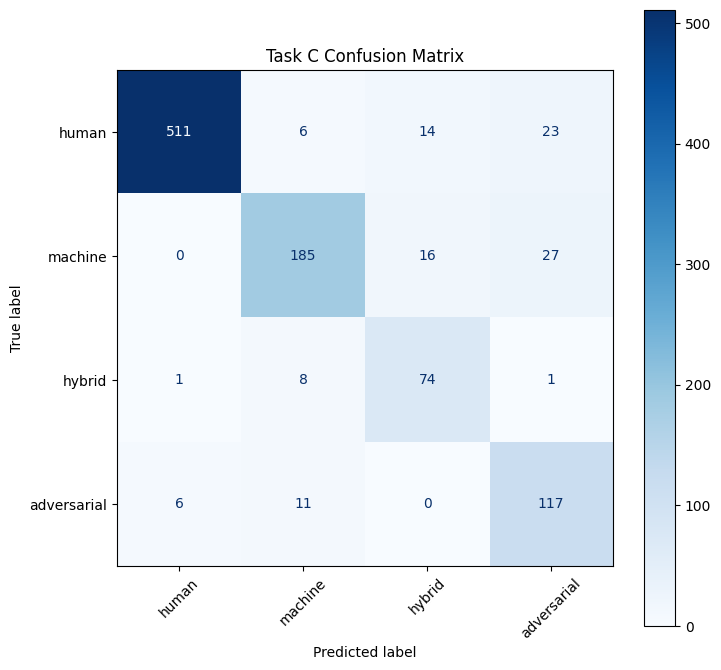

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[id2label[i] for i in range(CFG.num_labels)]
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)

plt.title("Task C Confusion Matrix")

# Save the figure
plt.savefig("task_c_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# Confusion Matrix normalizzata
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[id2label[i] for i in range(CFG.num_labels)],
    columns=[id2label[i] for i in range(CFG.num_labels)],
)

print(cm_norm_df.round(3))

             human  machine  hybrid  adversarial
human        0.922    0.011   0.025        0.042
machine      0.000    0.811   0.070        0.118
hybrid       0.012    0.095   0.881        0.012
adversarial  0.045    0.082   0.000        0.873
